# Escalado y Redución de la dimensionalidad de los datos usando PCA y t-SNE

### Importamos las librerías que vamos a utilizar en esta etapa del trabajo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from funciones_mecanizados import normalizar
from funciones_mecanizados import cortar
from funciones_mecanizados import pca

### Cargamos los archivos de cada una de las herramientas que previamente fuerón etiquetados cada uno de sus mecanizados. 

In [2]:
h1 = pd.read_csv('data/panel1_H1.csv')
h2 = pd.read_csv('data/panel2_H2.csv')
h3 = pd.read_csv('data/panel1_H3.csv')
h3_ = pd.read_csv('data/panel2_H3.csv')

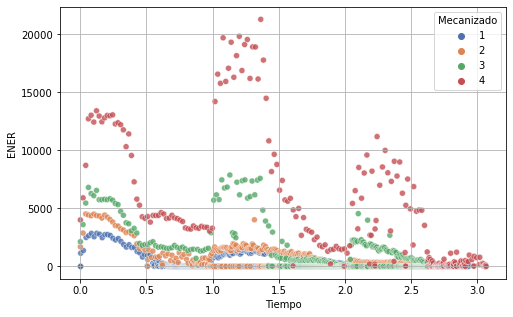

In [3]:
#Plot dataset separado por mecanizados
plt.figure(figsize=(8,5))
var = 'ENER'
ch = 1
data=h2

sns.scatterplot(data=data[data['CH']==ch], x='Tiempo', y=var, hue='Mecanizado', palette='deep', alpha=0.8)
plt.legend(title='Mecanizado', loc=1)
plt.grid('True')

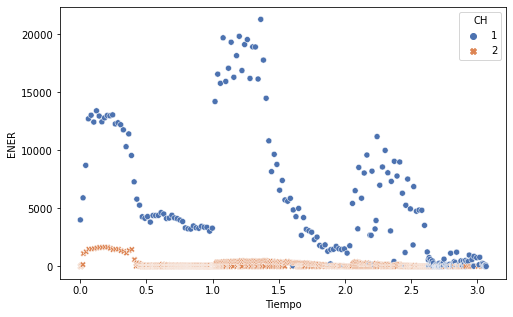

In [4]:
# Visualización de un mecanizado
plt.figure(figsize=(8,5))
var='ENER'
datos = h2
mecanizado = 4

sns.scatterplot(data=datos[datos['Mecanizado']==mecanizado], x='Tiempo', y=var, hue='CH', palette='deep', style="CH")
plt.show()

### Eliminamos los datos que consideramos como ruido utilizando como referencia la energía.

In [5]:
nivel = 1000

h1.drop(h1[h1['ENER']<nivel].index, axis=0, inplace=True)
h2.drop(h2[h2['ENER']<nivel].index, axis=0, inplace=True)
h3.drop(h3[h3['ENER']<nivel].index, axis=0, inplace=True)
h3_.drop(h3_[h3_['ENER']<nivel].index, axis=0, inplace=True)

### Normalizamos cada uno de los mecanizados.

In [6]:
columnas = ['RMS','AMP','ENER','P_FRQ','PCNTS','C_FRQ', 'I_FRQ','A_FRQ',
            'R_FRQ','DURATION','ASL','COUN','ABS_ENERGY', 'SIG_STRNGTH','RISE']

metodo = 'MinMaxScaler'
h1_norm = normalizar(h1, columnas, metodo)
h2_norm = normalizar(h2, columnas, metodo)
h3_norm = normalizar(h3, columnas, metodo)

### Extraemos los datos que corresponden a la etapa del fresado de cada una de las herramienta.

In [7]:
corte1 = [1,1.4]
corte2 = [2,2.4]

fresado_h1 = pd.concat([cortar(h1_norm, corte1), cortar(h1_norm, corte2)])
fresado_h2 = pd.concat([cortar(h2_norm, corte1), cortar(h2_norm, corte2)])
fresado_h3 = pd.concat([cortar(h3_norm, corte1), cortar(h3_norm, corte2)])

print('H1:',fresado_h1.shape)
print('H2:',fresado_h2.shape)
print('H3:',fresado_h3.shape)

H1: (163, 19)
H2: (350, 19)
H3: (226, 19)


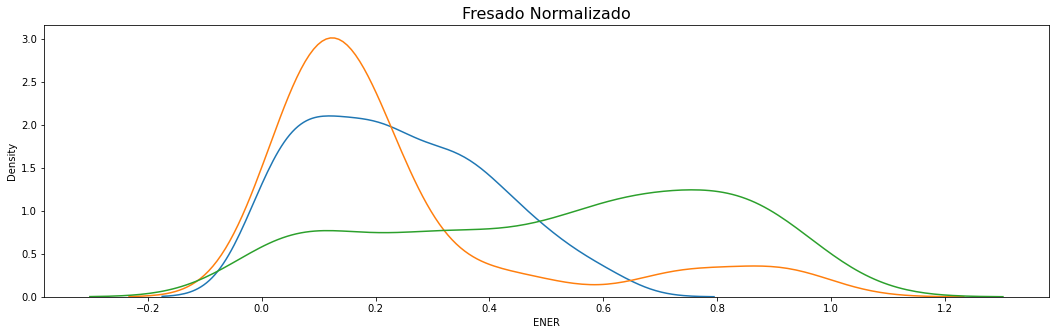

In [8]:
plt.figure(figsize=(18,5))

var = 'ENER'
plt.title('Fresado Normalizado', size=16)

sns.kdeplot(fresado_h1[var], shade=False, palette='deep')

sns.kdeplot(fresado_h2[var],shade=False, palette='deep')

sns.kdeplot(fresado_h3[var],shade=False, palette='deep')
plt.show()

### Aplicamos el PCA

In [9]:
cols =  ['RMS','AMP','ENER','P_FRQ','PCNTS','C_FRQ', 'I_FRQ','A_FRQ',
            'R_FRQ','DURATION','ASL','COUN','ABS_ENERGY', 'SIG_STRNGTH','RISE']

pc_df, pca_model = pca([fresado_h1,fresado_h2,fresado_h3], cols)

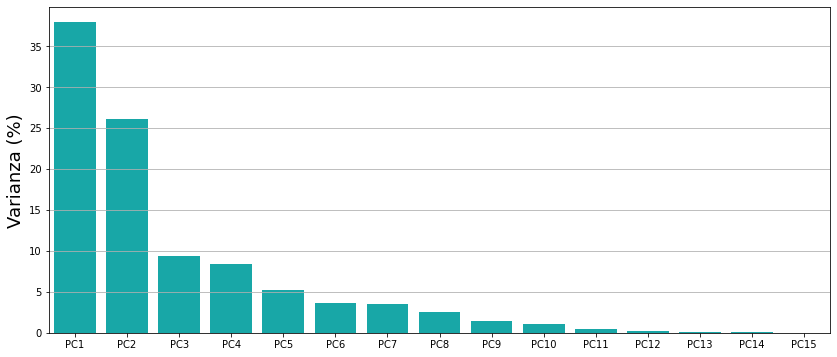

In [10]:
varianza_df = pd.DataFrame({'Varianza':np.round(pca_model.explained_variance_ratio_*100,4), 'PC':list(pc_df.columns.drop(['Herramienta','Mecanizado','CH']))})

plt.figure(figsize=(14,6))

sns.barplot(x='PC', y='Varianza', data=varianza_df, color='c')

plt.xlabel('')
plt.ylabel('Varianza (%)', size=18)
plt.grid(True, axis='y')

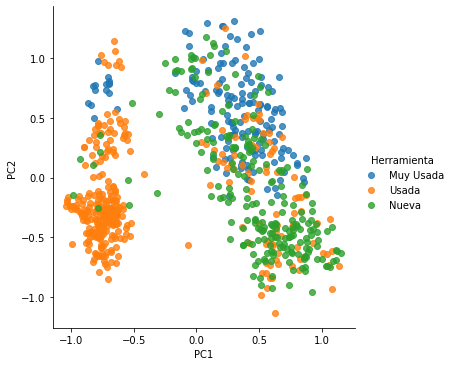

In [11]:
sns.lmplot(x='PC1', y='PC2', data=pc_df, fit_reg=False, hue='Herramienta', legend=True)
plt.show()

<IPython.core.display.Javascript object>


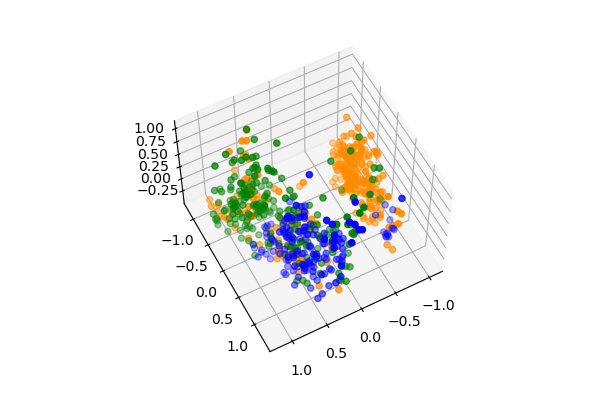

In [12]:
#%%grafica 3d
%matplotlib notebook

fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111, projection='3d')

pc_df_H1 = pc_df[pc_df['Herramienta']=='Muy Usada']
pc_df_H2 = pc_df[pc_df['Herramienta']=='Usada']
pc_df_H3 = pc_df[pc_df['Herramienta']=='Nueva'] 

ax1.scatter(pc_df_H1['PC1'],pc_df_H1['PC2'],pc_df_H1['PC3'], c='b' , marker='o')
ax1.scatter(pc_df_H2['PC1'],pc_df_H2['PC2'],pc_df_H2['PC3'], c='darkorange' , marker='o')
ax1.scatter(pc_df_H3['PC1'],pc_df_H3['PC2'],pc_df_H3['PC3'], c='g' , marker='o')
plt.show()